In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("tmdb_5000_movies.csv")

print(df.shape)
df.head()

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [7]:
import subprocess
subprocess.run(["python", "-m", "pip", "install", "matplotlib", "seaborn"])

CompletedProcess(args=['python', '-m', 'pip', 'install', 'matplotlib', 'seaborn'], returncode=0)

In [9]:
# Drop rows where budget or revenue is 0
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

# Create ROI column
df['roi'] = (df['revenue'] - df['budget']) / df['budget'] * 100

# Extract release year
df['release_year'] = pd.to_datetime(df['release_date']).dt.year

# Extract decade
df['decade'] = (df['release_year'] // 10) * 10

print(f"Rows after cleaning: {df.shape[0]}")
df.head()

Rows after cleaning: 3229


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,roi,release_year,decade
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,1076.356577,2009,2000
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,220.333333,2007,2000
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,259.459024,2015,2010
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,333.975640,2012,2010
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,9.284269,2012,2010


In [ ]:
import json

# Parse genres from JSON string into a list of genres
def parse_genres(genre_str):
    try:
        genres = json.loads(genre_str)
        return [g['name'] for g in genres]
    except:
        return []

df['genres_list'] = df['genres'].apply(parse_genres)

# Explode so each genre gets its own row
df_genres = df.explode('genres_list')
df_genres = df_genres[df_genres['genres_list'] != '']

print(df_genres['genres_list'].value_counts().head(10))

genres_list
Drama              1441
Comedy             1110
Thriller            935
Action              918
Adventure           661
Romance             574
Crime               521
Science Fiction     431
Family              365
Fantasy             342
Name: count, dtype: int64


In [12]:
# Check for nulls
print("Null values:")
print(df[['budget', 'revenue', 'roi', 'vote_average', 'release_date']].isnull().sum())

# Check for negative values
print("\nNegative ROI count:", (df['roi'] < 0).sum())
print("Negative budget count:", (df['budget'] < 0).sum())
print("Negative revenue count:", (df['revenue'] < 0).sum())

# Check for duplicates
print("Duplicate movie titles:", df['title'].duplicated().sum())

Null values:
budget          0
revenue         0
roi             0
vote_average    0
release_date    0
dtype: int64

Negative ROI count: 789
Negative budget count: 0
Negative revenue count: 0
Duplicate movie titles: 1


In [13]:
# Remove duplicate titles, keep first occurrence
df = df.drop_duplicates(subset='title', keep='first')
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 3228


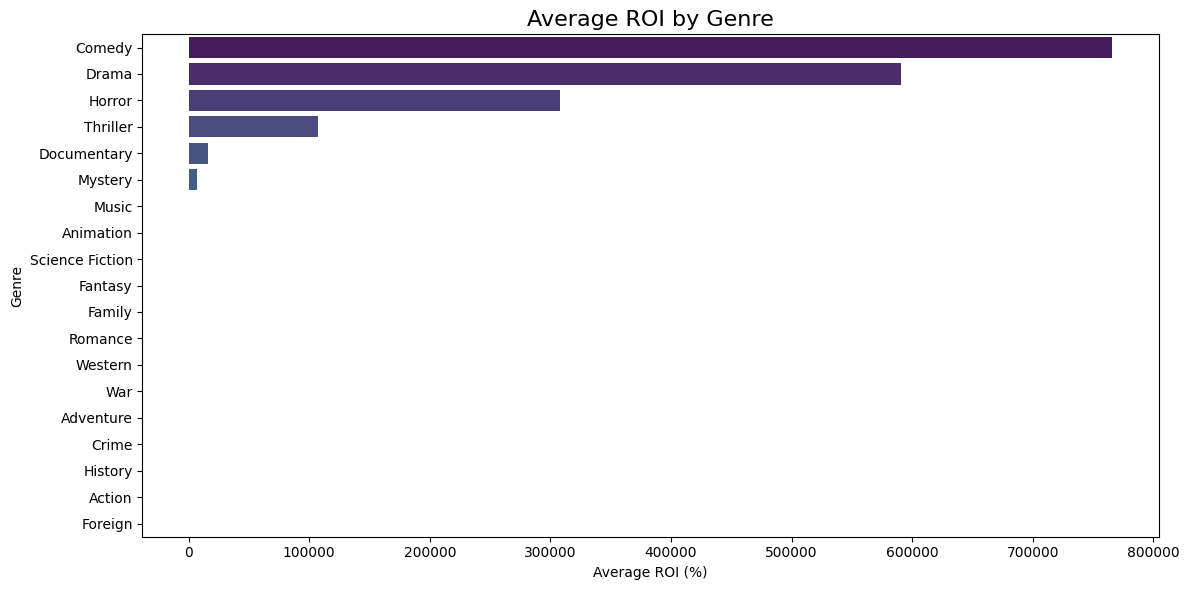

In [ ]:
# Group by genre and calculate mean ROI, then sort highest to lowest
roi_by_genre = df_genres.groupby('genres_list')['roi'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# Draw a horizontal bar chart
sns.barplot(x=roi_by_genre.values, y=roi_by_genre.index, hue=roi_by_genre.index, palette='viridis', legend=False)
# Add labels and title
plt.title('Average ROI by Genre', fontsize=16)
plt.xlabel('Average ROI (%)')
plt.ylabel('Genre')

plt.tight_layout()

plt.savefig('roi_by_genre.png')

plt.show()

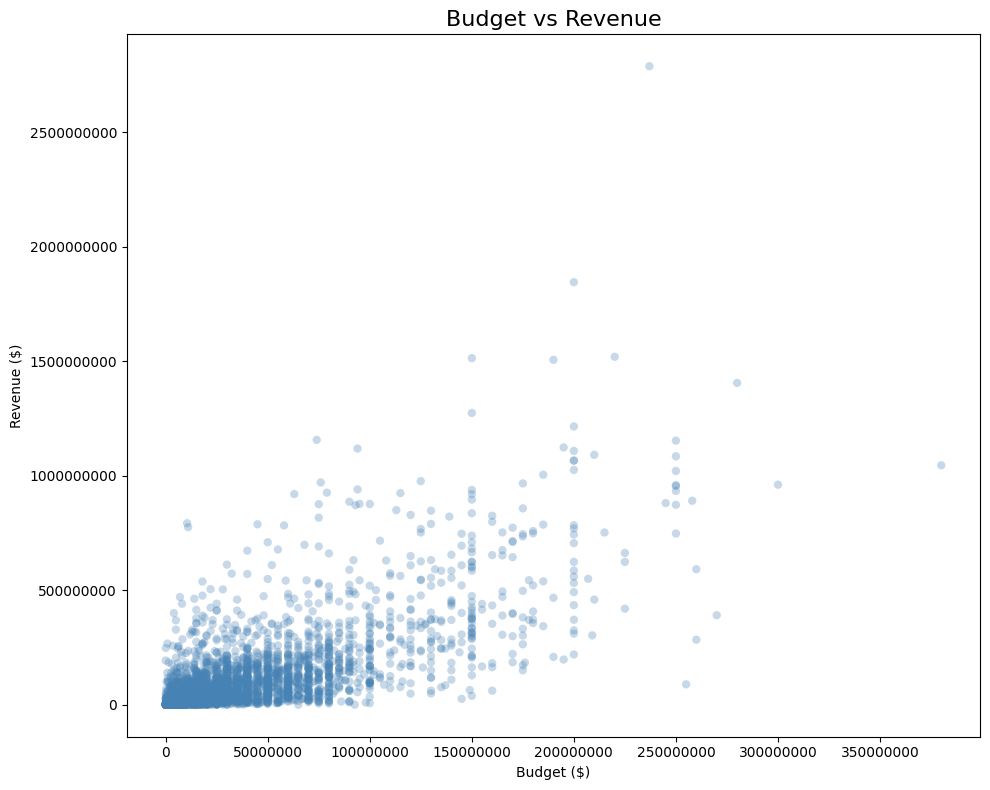

In [ ]:
plt.figure(figsize=(10, 8))


plt.scatter(df['budget'], df['revenue'], alpha=0.3, color='steelblue', edgecolors='none')

plt.title('Budget vs Revenue', fontsize=16)
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')

plt.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.savefig('budget_vs_revenue.png')
plt.show()

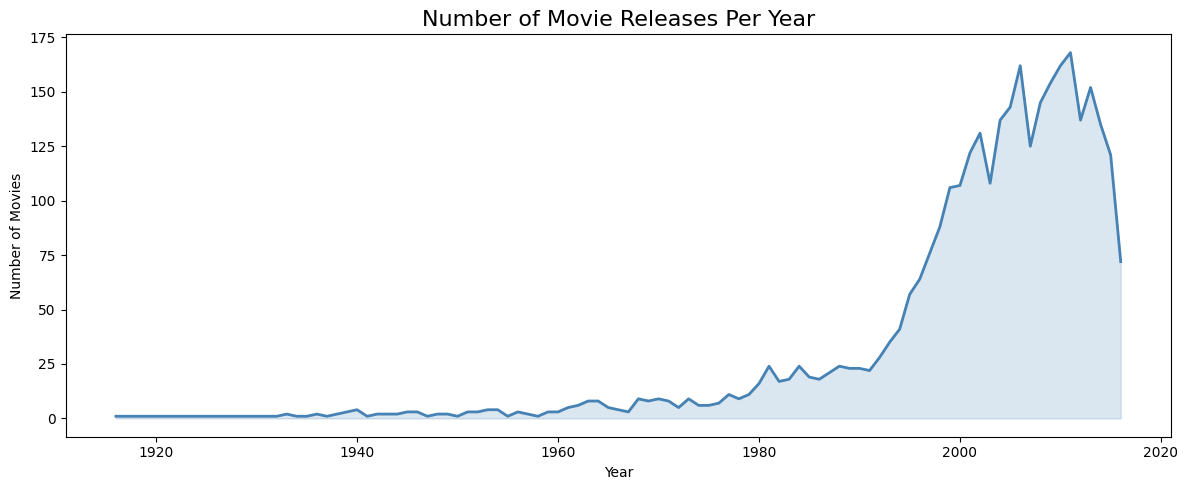

In [ ]:
# Count number of movies per year
movies_per_year = df.groupby('release_year')['title'].count()

plt.figure(figsize=(12, 5))

# Line chart showing trend over time
plt.plot(movies_per_year.index, movies_per_year.values, color='steelblue', linewidth=2)

plt.fill_between(movies_per_year.index, movies_per_year.values, alpha=0.2, color='steelblue')

plt.title('Number of Movie Releases Per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.savefig('releases_per_year.png')
plt.show()

C:\Users\cbena\AppData\Local\Temp\ipykernel_7144\3635151576.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genres_list', y='vote_average', data=df_top_genres, palette='viridis')


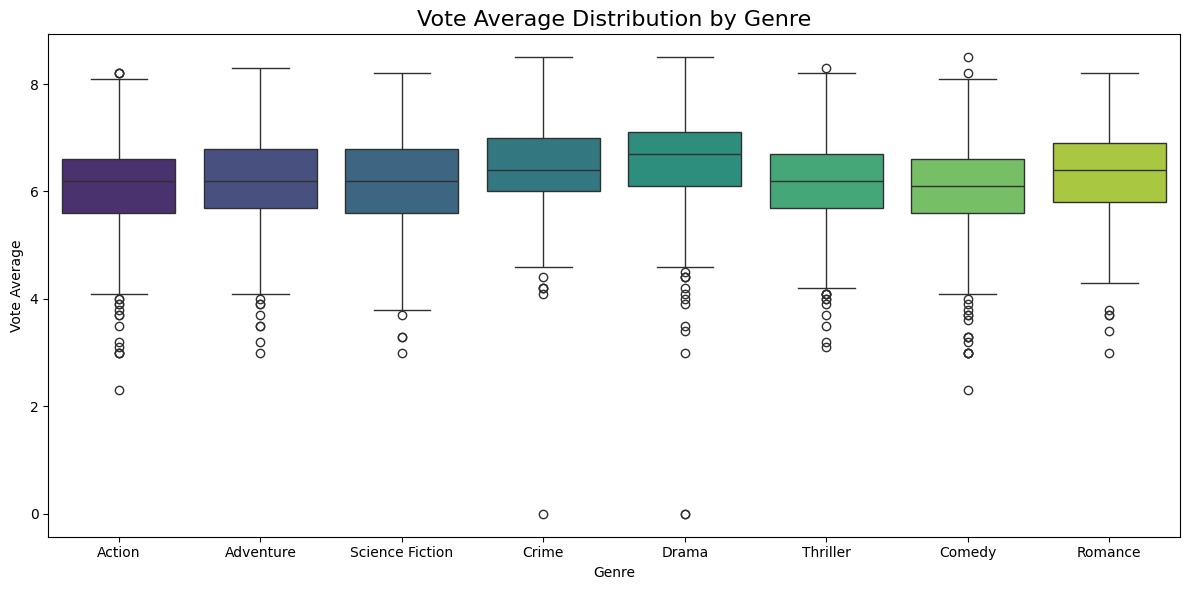

In [ ]:
# Get top 8 genres by movie count 
top_genres = df_genres['genres_list'].value_counts().head(8).index

# Filter to only those genres
df_top_genres = df_genres[df_genres['genres_list'].isin(top_genres)]

plt.figure(figsize=(12, 6))

# Box plot showing distribution of ratings per genre
sns.boxplot(x='genres_list', y='vote_average', data=df_top_genres, palette='viridis')

plt.title('Vote Average Distribution by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Vote Average')

plt.tight_layout()
plt.savefig('ratings_by_genre.png')
plt.show()